<a href="https://colab.research.google.com/github/fabrito2006/Laboratorio-13-MID/blob/develop/Laboratorio_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 13 - Mineria de Datos
## Alumno: Torres Alvaradao Fabricio Ismael
## Ciclo y carrera: 5C28A

## 1.	Tomando la información disponible en el repositorio UCI Machine Learning https://archive.ics.uci.edu/ml/datasets/Productivity+Prediction+of+Garment+Employees, pero eliminando previamente a la variable ‘date’ y definiendo a la variable ‘actual_productivity’ con base a dos categorías (0 cuando ‘actual_productivity’ < 0.5 y 1 cuando ‘actual_productivity’ ≥ 0.5) siendo esta la variable de clasificación, haga lo siguiente:

In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# fetch dataset
productivity_prediction_of_garment_employees = fetch_ucirepo(id=597)

# data (as pandas dataframes)
X = productivity_prediction_of_garment_employees.data.features
y = productivity_prediction_of_garment_employees.data.targets

# Concat data
data = pd.concat([X, y], axis=1)

In [3]:
data.head(10)

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
5,1/1/2015,Quarter1,sweing,Thursday,7,0.80,25.90,984.0,6720,38,0.0,0,0,56.0,0.800125
6,1/1/2015,Quarter1,finishing,Thursday,2,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.755167
7,1/1/2015,Quarter1,sweing,Thursday,3,0.75,28.08,795.0,6900,45,0.0,0,0,57.5,0.753683
8,1/1/2015,Quarter1,sweing,Thursday,2,0.75,19.87,733.0,6000,34,0.0,0,0,55.0,0.753098
9,1/1/2015,Quarter1,sweing,Thursday,1,0.75,28.08,681.0,6900,45,0.0,0,0,57.5,0.750428


In [4]:
# Eliminamos la variable date
data = data.drop(columns='date',axis=1)

In [5]:
# Cambiamos la variable actual productivity
data['actual_productivity'] = data['actual_productivity'].apply(lambda x: 1 if x >= 0.5 else 0)
data.head(10)

,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,1
1,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,1
2,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,1
3,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,1
4,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,1
5,Quarter1,sweing,Thursday,7,0.80,25.90,984.0,6720,38,0.0,0,0,56.0,1
6,Quarter1,finishing,Thursday,2,0.75,3.94,NaN,960,0,0.0,0,0,8.0,1
7,Quarter1,sweing,Thursday,3,0.75,28.08,795.0,6900,45,0.0,0,0,57.5,1
8,Quarter1,sweing,Thursday,2,0.75,19.87,733.0,6000,34,0.0,0,0,55.0,1
9,Quarter1,sweing,Thursday,1,0.75,28.08,681.0,6900,45,0.0,0,0,57.5,1


### a.	Realice el preprocesamiento de la información que incluya el análisis de datos faltantes y tratamiento de outliers a nivel univariado y multivariado. Además, convierta las variables categóricas a dummies y aplique un escalamiento a las variables numéricas.

#### Imputamos datos nulos

In [6]:
# Visualizamos los valores nulos
columnas_nulas = data.columns[data.isnull().any()]
print(columnas_nulas)
data.isnull().sum()

Index(['wip'], dtype='object')


,0
quarter,0
department,0
day,0
team,0
targeted_productivity,0
smv,0
wip,506
over_time,0
incentive,0
idle_time,0


In [7]:
# Funcion para rellenar con la mediana
def rellenar_nulos_con_mediana(data, columnas):
    for columna in columnas:
        mediana = data[columna].median()
        data[columna] = data[columna].apply(lambda x: mediana if pd.isnull(x) else x)
        print(f"Se ha rellenado la columna '{columna}' con la mediana: {mediana}")
    return data

In [8]:
# Rellenar columnas
data = rellenar_nulos_con_mediana(data, columnas_nulas)

Se ha rellenado la columna 'wip' con la mediana: 1039.0


In [9]:
# Verificamos
columnas_nulas = data.columns[data.isnull().any()]
print(columnas_nulas)
data.isnull().sum()

Index([], dtype='object')


,0
quarter,0
department,0
day,0
team,0
targeted_productivity,0
smv,0
wip,0
over_time,0
incentive,0
idle_time,0


#### Tratamiento de outliers

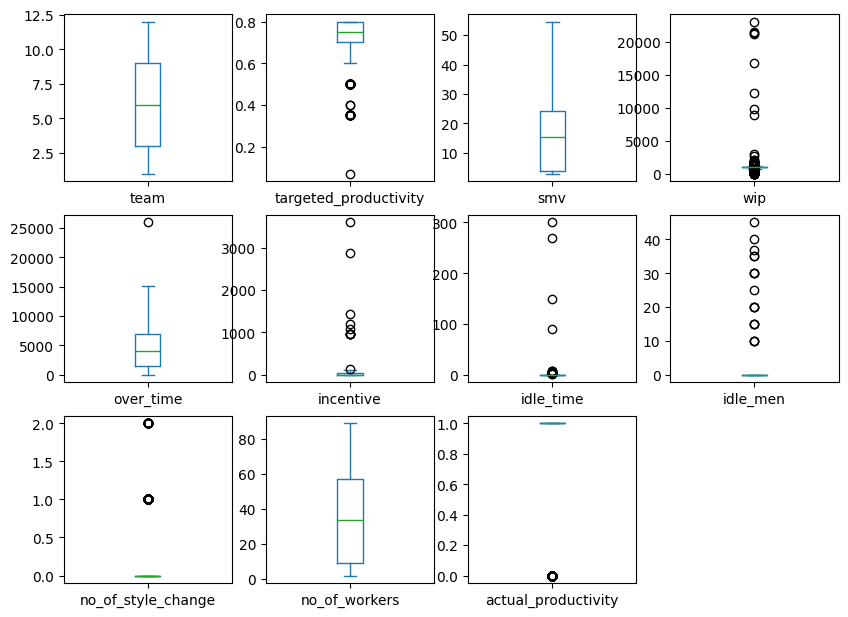

In [10]:
# Visualizamos los outliers
import matplotlib.pyplot as plt
data.plot(kind='box', subplots=True, layout=(4,4), sharex=False, sharey=False, figsize=(10,10))
plt.show()

In [11]:
# Funcion para hallar los outliers
def cap_outliers_iqr(data, var):
    Q1 = data[var].quantile(0.25)
    Q3 = data[var].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    data[var] = data[var].apply(lambda x: lim_sup if x > lim_sup else (lim_inf if x < lim_inf else x))
    return data

In [12]:
# Aplicamos el capping para las variables Age y Weight
data = cap_outliers_iqr(data, 'wip')
data = cap_outliers_iqr(data, 'targeted_productivity')
data = cap_outliers_iqr(data, 'over_time')
data = cap_outliers_iqr(data, 'incentive')

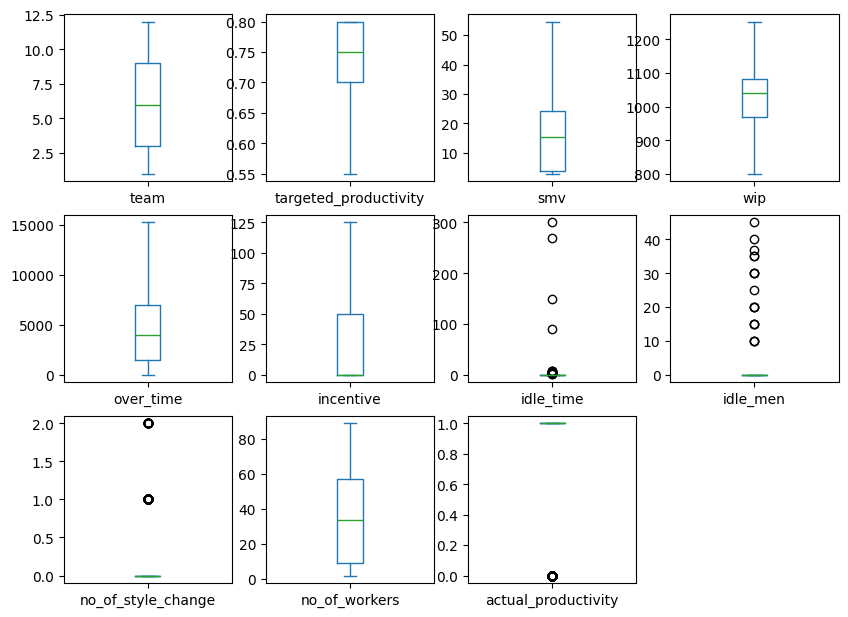

In [13]:
# Visualizamos los outliers
import matplotlib.pyplot as plt
data.plot(kind='box', subplots=True, layout=(4,4), sharex=False, sharey=False, figsize=(10,10))
plt.show()

#### Variables categoricas a dummies

In [14]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.7 MB/s eta 0:00:00


In [15]:
# Seleccionamos las variables categóricas:
columnas_categoricas = ['department', 'quarter', 'day']

In [16]:
# Separar la variable objetivo
y = data['actual_productivity']
X = data.drop(columns='actual_productivity')

In [17]:
import category_encoders as ce

# Aplicar OneHotEncoder
encoder = ce.OneHotEncoder(cols=columnas_categoricas, use_cat_names=True)
X = encoder.fit_transform(X)

# Ver resultado
print(X.head())

   quarter_Quarter1  quarter_Quarter2  quarter_Quarter3  quarter_Quarter4  \
0                 1                 0                 0                 0   
1                 1                 0                 0                 0   
2                 1                 0                 0                 0   
3                 1                 0                 0                 0   
4                 1                 0                 0                 0   

   quarter_Quarter5  department_sweing  department_finishing  day_Thursday  \
0                 0                  1                     0             1   
1                 0                  0                     1             1   
2                 0                  1                     0             1   
3                 0                  1                     0             1   
4                 0                  1                     0             1   

   day_Saturday  day_Sunday  ...  team  targeted_productivity    smv

#### Escalamiento de variables

In [18]:
from sklearn.preprocessing import StandardScaler

# Crear el escalador
scaler = StandardScaler()

# Aplicar solo a las columnas 'wip' y 'over_time'
X[['wip', 'over_time']] = scaler.fit_transform(X[['wip', 'over_time']])

### b.	Separe los datos en entrenamiento (80%) y prueba (20%) y entrene los modelos k-NN, SVM, regresión logística, árbol de clasificación, Random Forest y Naive Bayes definiendo distintos hiperparámetros para cada modelo.

In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [20]:
from sklearn.preprocessing import StandardScaler
data_estand = StandardScaler()
X_train = data_estand.fit_transform(X_train)
X_test = data_estand.transform(X_test)

In [21]:
from sklearn.svm import SVC

In [22]:
from sklearn.model_selection import GridSearchCV
parameters = {'kernel':['linear','rbf','poly'],'C':[0.1,0.5,1,5,10]}
svm = GridSearchCV(SVC(),parameters)
svm.fit(X_train,y_train)
print("accuracy = ",svm.score(X_test,y_test))
print("Los mejores parámetros: ",svm.best_params_)

accuracy =  0.8958333333333334
Los mejores parámetros:  {'C': 0.1, 'kernel': 'poly'}


In [23]:
from sklearn.model_selection import RandomizedSearchCV
parameters = {'kernel':['linear','rbf','poly'],'C':[0.1,0.5,1,5,10]}
svm = RandomizedSearchCV(SVC(),parameters)
svm.fit(X_train,y_train)
print("accuracy = ",svm.score(X_test,y_test))
print("Los mejores parámetros: ",svm.best_params_)

accuracy =  0.8958333333333334
Los mejores parámetros:  {'kernel': 'poly', 'C': 0.1}


In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [25]:
columnas = ['Case', 'k-NN','SVM','Random Forest','Regresión logística']
resultados = pd.DataFrame(columns=columnas)
resultados.set_index('Case',inplace=True)
resultados.loc['Standard'] = [0,0,0,0]
resultados.loc['GridSearch'] = [0,0,0,0]
resultados.loc['RandomSearch'] = [0,0,0,0]
resultados.loc['Hyperopt'] = [0,0,0,0]
resultados.head()

,k-NN,SVM,Random Forest,Regresión logística
Case,,,,
Standard,0,0,0,0
GridSearch,0,0,0,0
RandomSearch,0,0,0,0
Hyperopt,0,0,0,0


In [26]:
knn = KNeighborsClassifier()
svm = SVC()
rf = RandomForestClassifier()
lr = LogisticRegression()

In [27]:
modelos = [knn,svm,rf,lr]
col = 0
for modelo in modelos:
    modelo.fit(X_train,y_train.values.ravel())
    resultados.iloc[0,col] = modelo.score(X_test,y_test)
    col += 1

resultados.head()

<ipython-input-27-3180563017>:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9041666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  resultados.iloc[0,col] = modelo.score(X_test,y_test)
<ipython-input-27-3180563017>:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.8916666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  resultados.iloc[0,col] = modelo.score(X_test,y_test)
<ipython-input-27-3180563017>:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9125' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  resultados.iloc[0,col] = modelo.score(X_test,y_test)
<ipython-input-27-3180563017>:5: FutureW

,k-NN,SVM,Random Forest,Regresión logística
Case,,,,
Standard,0.904167,0.891667,0.9125,0.891667
GridSearch,0.000000,0.000000,0.0000,0.000000
RandomSearch,0.000000,0.000000,0.0000,0.000000
Hyperopt,0.000000,0.000000,0.0000,0.000000


### c.	Utilice hiperparámetros estándar, la búsqueda en cuadrícula y búsqueda aleatoria para poder encontrar el modelo de clasificación con mejor desempeño. Luego, obtenga el mejor accuracy junto con los hiperparámetros óptimos para dicho modelo.

In [28]:
# k-NN
knn_grid = {
    'n_neighbors': list(range(1, 21, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Support Vector Machines
svm_grid = {
    'kernel': ['poly', 'rbf', 'sigmoid'],
    'C': [50, 10, 1, 0.1, 0.01],
    'gamma': ['scale']
}

# Random Forest
rf_grid = {
    'n_estimators': [10, 100, 1000, 10000],
    'max_features': ['sqrt', 'log2']
}

# Regresión Logística
lr_grid = {
    'solver': ['newton-cg', 'lbfgs', 'liblinear'],
    'penalty': ['l2'],
    'C': [100, 10, 1, 0.1, 0.01]
}

In [30]:
# Lista de modelos y grids
models = [
    KNeighborsClassifier(),
    SVC(),
    RandomForestClassifier(),
    LogisticRegression(max_iter=1000)
]

grids = [knn_grid, svm_grid, rf_grid, lr_grid]

In [34]:
from sklearn.model_selection import StratifiedKFold

# Solo 5 folds y sin repeticiones
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

# Solo un par de combinaciones de hiperparámetros
n_iter_search = 2  # En vez de 3


col = 0
for ind in range(len(models_to_test)):
    random_search = RandomizedSearchCV(models_to_test[ind],
                                       param_distributions=grids_to_test[ind],
                                       n_iter=n_iter_search,
                                       cv=cv,
                                       n_jobs=-1)  # Usa todos los cores disponibles
    random_search.fit(X_train, y_train)
    resultados.iloc[2, col] = random_search.score(X_test, y_test)
    col += 1

resultados.head()

,k-NN,SVM,Random Forest,Regresión logística
Case,,,,
Standard,0.904167,0.891667,0.9125,0.891667
GridSearch,0.000000,0.000000,0.0000,0.000000
RandomSearch,0.895833,0.895833,0.0000,0.000000
Hyperopt,0.000000,0.000000,0.0000,0.000000


In [38]:
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV

cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=1, random_state=1)  # ↓ menos validaciones
n_iter_search = 2  # ↓ menos combinaciones

col = 0
for ind in range(len(models)):
    print(f"Entrenando modelo: {models[ind]}")  # opcional, para seguimiento
    random_search = RandomizedSearchCV(
        estimator=models[ind],
        param_distributions=grids[ind],
        n_iter=n_iter_search,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,         # ↑ acelera con múltiples núcleos
        random_state=1,
        verbose=1          # opcional: ver progreso
    )
    random_search.fit(X_train, y_train)
    resultados.iloc[2, col] = random_search.score(X_test, y_test)
    col += 1

resultados.head()

Entrenando modelo: KNeighborsClassifier()
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Entrenando modelo: SVC()
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Entrenando modelo: RandomForestClassifier()
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Entrenando modelo: LogisticRegression(max_iter=1000)
Fitting 3 folds for each of 2 candidates, totalling 6 fits


,k-NN,SVM,Random Forest,Regresión logística
Case,,,,
Standard,0.904167,0.891667,0.9125,0.891667
GridSearch,0.000000,0.000000,0.0000,0.000000
RandomSearch,0.895833,0.891667,0.9000,0.891667
Hyperopt,0.000000,0.000000,0.0000,0.000000


In [39]:
cv = RepeatedStratifiedKFold(n_splits=10,n_repeats=3,random_state=1)
n_iter_search = 3
grid_search = GridSearchCV(estimator=lr,param_grid=lr_grid,
                           n_jobs=-1,cv=cv,
                           scoring='accuracy',error_score=0)
grid_ganador = grid_search.fit(X_train,y_train)
print("Mejor: %f usando %s" % (grid_ganador.best_score_,grid_ganador.best_params_))

Mejor: 0.898673 usando {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


In [40]:
!pip install scikit-plot

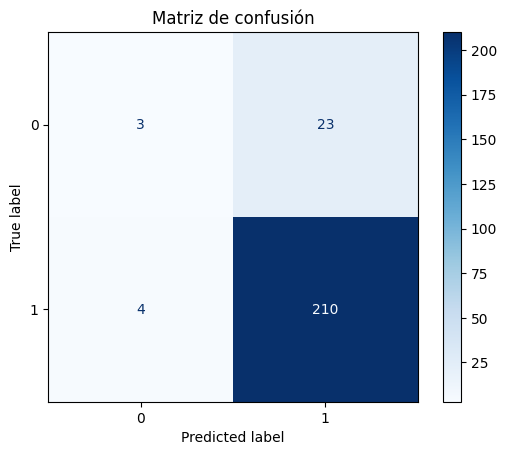

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

y_pred = grid_ganador.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de confusión")
plt.show()